# 01. Exploration: what the missing values are hiding

**Question.** Notebook 00 established that 8 columns of this file are almost empty while
the rest are almost full. This notebook asks whether the pattern of absence carries
information about the class, and if so how to turn it into variables.

**Inputs.** `data/raw/aps_failure_training_set.csv`.

**Outputs.** Six `01_*` figures in `reports/figures/`, and decisions D-09 and D-10,
recorded in `docs/technical_decisions.md`.

**Rule respected throughout.** Every measurement that feeds a modelling decision is
taken on the 48 000 fitting rows only. The 12 000 validation rows are used once, in
section 2, to show what the split choice costs, and never to select anything.

In [1]:
import sys
from pathlib import Path

sys.path.insert(0, str(Path.cwd().parent))

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

from src.config import FIGURES_DIR
from src.seeding import set_seed

set_seed()
FIGURES_DIR.mkdir(parents=True, exist_ok=True)
pd.set_option('display.width', 120)

2026-09-02 14:20:03.918676: I tensorflow/core/util/port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
2026-09-02 14:20:03.966062: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 AVX_VNNI FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.


## 1. The split, before anything else

Nothing measured after this cell can leak into the validation part, because the split
has already happened.

In [2]:
from src.data import train_validation_split

X_fit, X_val, y_fit, y_val = train_validation_split()
print('fitting   ', X_fit.shape, int(y_fit.sum()), 'failures', f'{y_fit.mean():.4%}')
print('validation', X_val.shape, int(y_val.sum()), 'failures', f'{y_val.mean():.4%}')
print('split checksum :', f'{int(X_val.index.to_numpy().sum()):,}')

assert len(X_fit) + len(X_val) == 60_000
assert int(y_fit.sum()) + int(y_val.sum()) == 1_000
assert not set(X_fit.index) & set(X_val.index)

fitting    (48000, 170) 800 failures 1.6667%
validation (12000, 170) 200 failures 1.6667%
split checksum : 357,794,337


## 2. Why 20%, and why stratified

Two separate choices, each with a measurable consequence.

**The size.** What the validation part has to measure is a detection rate, and the
precision of that measurement depends on the number of failures it contains, not on the
number of rows. Below 200 failures the standard error grows fast enough to make the
measurement useless for arbitration.

In [3]:
shares = np.array([0.10, 0.15, 0.20, 0.25, 0.30])
n_failures = (1000 * shares).astype(int)
# standard error of a proportion, at an assumed 90% detection rate
error = np.sqrt(0.9 * 0.1 / n_failures)

table = pd.DataFrame({'validation_share': shares,
                      'rows': (60_000 * shares).astype(int),
                      'failures': n_failures,
                      'failures_for_fitting': 1000 - n_failures,
                      'standard_error_pts': (error * 100).round(2)})
table

,validation_share,rows,failures,failures_for_fitting,standard_error_pts
0,0.10,6000,100,900,3.00
1,0.15,9000,150,850,2.45
2,0.20,12000,200,800,2.12
3,0.25,15000,250,750,1.90
4,0.30,18000,300,700,1.73


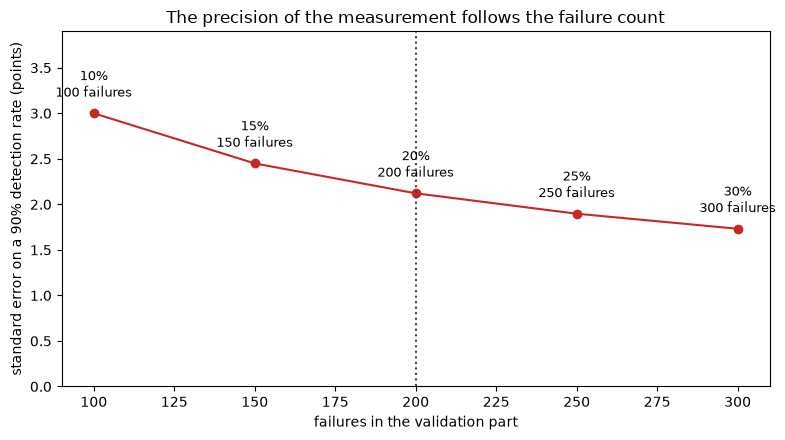

In [4]:
fig, ax = plt.subplots(figsize=(8, 4.5))
ax.plot(n_failures, error * 100, 'o-', color='#c62828')
for share, n, e in zip(shares, n_failures, error):
    ax.annotate(f'{share:.0%}\n{n} failures', (n, e * 100),
                xytext=(0, 12), textcoords='offset points', ha='center', fontsize=9)
ax.axvline(200, color='#37474f', ls=':', lw=1.5)
ax.set_xlabel('failures in the validation part')
ax.set_ylabel('standard error on a 90% detection rate (points)')
ax.set_title('The precision of the measurement follows the failure count')
ax.set_ylim(0, error.max() * 130)
fig.tight_layout()
fig.savefig(FIGURES_DIR / '01_split_size.png', dpi=150)

**The stratification.** Without it, the positive rate of the validation part is itself a
random variable. The simulation below draws 500 unstratified splits and reads off the
range.

The range matters for a specific reason: it straddles 1.96%, the rate at which the two
constant rules cost the same. An unstratified draw can therefore change which constant
rule is the reference to beat, which is a moving benchmark.

In [5]:
from src.config import BAYES_THRESHOLD

y_all = pd.concat([y_fit, y_val]).to_numpy()
rng = np.random.default_rng(42)
rates = np.array([y_all[rng.permutation(len(y_all))[:12_000]].mean()
                  for _ in range(500)])

print(f'unstratified : {rates.min():.4%} to {rates.max():.4%}, '
      f'std {rates.std():.4%}')
print(f'stratified   : {y_val.mean():.4%}, exact by construction')
print(f'break-even   : {BAYES_THRESHOLD:.4%}')
print(f'draws landing above the break-even rate : '
      f'{(rates > BAYES_THRESHOLD).mean():.1%}')

unstratified : 1.3333% to 1.9833%, std 0.1044%
stratified   : 1.6667%, exact by construction
break-even   : 1.9608%
draws landing above the break-even rate : 0.2%


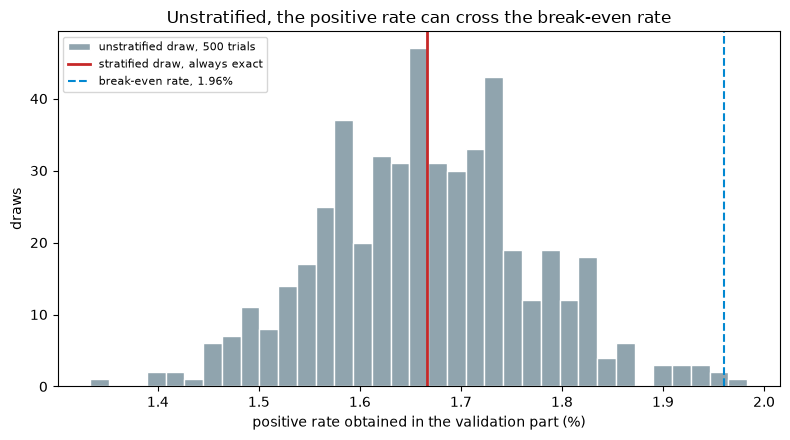

In [6]:
fig, ax = plt.subplots(figsize=(8, 4.5))
ax.hist(rates * 100, bins=35, color='#90a4ae', edgecolor='white',
        label='unstratified draw, 500 trials')
ax.axvline(y_all.mean() * 100, color='#c62828', lw=2,
           label='stratified draw, always exact')
ax.axvline(BAYES_THRESHOLD * 100, color='#0288d1', lw=1.5, ls='--',
           label='break-even rate, 1.96%')
ax.set_xlabel('positive rate obtained in the validation part (%)')
ax.set_ylabel('draws')
ax.set_title('Unstratified, the positive rate can cross the break-even rate')
ax.legend(fontsize=8)
fig.tight_layout()
fig.savefig(FIGURES_DIR / '01_stratification.png', dpi=150)

## 3. Absence depends on the class

The decisive measurement: the missing rate of each column computed separately inside
each class. If absence were a random sensor fault, the two rates would coincide. They do
not, and the gap has two signs.

In [7]:
from src.missingness import detect_groups, per_class_missing_rate

groups = detect_groups(X_fit, y_fit)
print('group 1 :', len(groups['group1']), 'columns ->', groups['group1'])
print('group 2 :', len(groups['group2']), 'columns')
print('mute    :', len(groups['mute']), 'columns')

group 1 : 8 columns -> ['bk_000', 'bl_000', 'bm_000', 'bn_000', 'bo_000', 'bp_000', 'bq_000', 'br_000']
group 2 : 56 columns
mute    : 106 columns


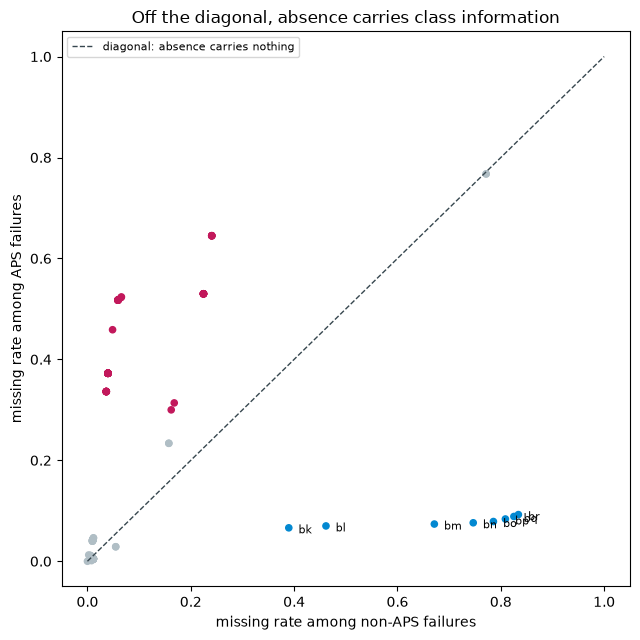

In [8]:
rates = per_class_missing_rate(X_fit, y_fit)
colour = np.where(rates.index.isin(groups['group1']), '#0288d1',
                  np.where(rates.index.isin(groups['group2']), '#c2185b', '#b0bec5'))

fig, ax = plt.subplots(figsize=(6.5, 6.5))
ax.scatter(rates['rate_other'], rates['rate_aps'], c=colour, s=20)
ax.plot([0, 1], [0, 1], color='#37474f', lw=1, ls='--',
        label='diagonal: absence carries nothing')
for column in groups['group1']:
    ax.annotate(column.replace('_000', ''),
                (rates.loc[column, 'rate_other'], rates.loc[column, 'rate_aps']),
                xytext=(7, -4), textcoords='offset points', fontsize=8)
ax.set_xlabel('missing rate among non-APS failures')
ax.set_ylabel('missing rate among APS failures')
ax.set_title('Off the diagonal, absence carries class information')
ax.legend(loc='upper left', fontsize=8)
fig.tight_layout()
fig.savefig(FIGURES_DIR / '01_scatter_by_class.png', dpi=150)

### Where the 0.10 threshold falls

The threshold was written down before the computation it selects on. That is discipline,
not evidence. The question of whether it also happens to fall in a sensible place is a
separate one, and it has different answers on the two sides.

On the group 1 side there is a genuine break: the eighth largest gap is above 0.32 and
the ninth is below 0.03. Any threshold between the two selects the same eight columns.

On the group 2 side there is no comparable break. The threshold there is a declared
choice and nothing more, and it is reported as such.

In [9]:
from src.missingness import gap_cliff

cliff = gap_cliff(X_fit, y_fit)
for side in ('group1_cliff', 'group2_cliff'):
    drop = cliff[side]
    print(f'{side:<13} last selected {drop["last_selected"]:.4f}, '
          f'next {drop["next"]:.4f}, factor {drop["factor"]:.1f}')
print()
print(cliff['gap'].head(12).to_string())

group1_cliff  last selected 0.3234, next 0.0260, factor 12.4
group2_cliff  last selected 0.1379, next 0.0763, factor 1.8

br_000    0.741483
bq_000    0.736547
bp_000    0.725085
bo_000    0.706907
bn_000    0.670360
bm_000    0.597585
bl_000    0.391631
bk_000    0.323411
bx_000    0.025996
cc_000    0.025953
by_000    0.006631
ba_007    0.006356


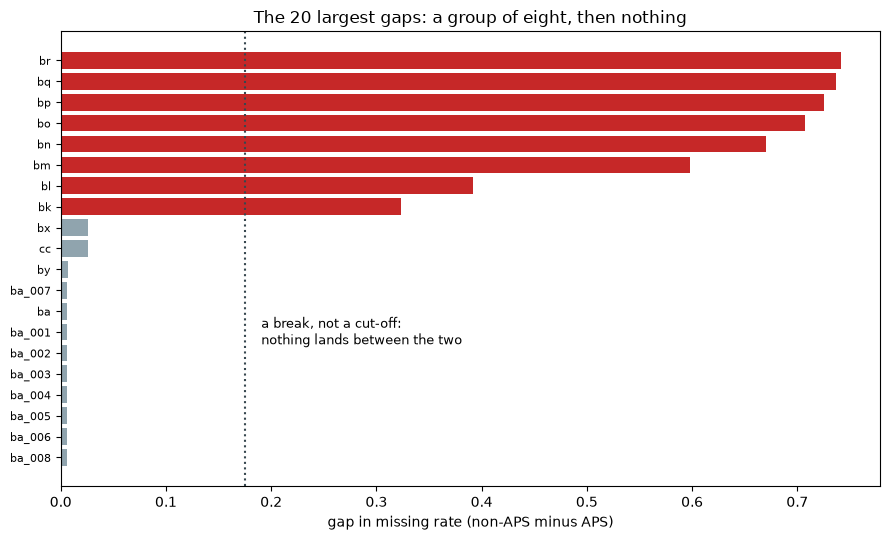

In [10]:
gap = cliff['gap']
top = gap.head(20)
colour = ['#c62828' if c in groups['group1'] else '#90a4ae' for c in top.index]

fig, ax = plt.subplots(figsize=(9, 5.5))
position = np.arange(len(top))[::-1]
ax.barh(position, top.values, color=colour)
ax.set_yticks(position)
ax.set_yticklabels([c.replace('_000', '') for c in top.index], fontsize=8)
boundary = (top.values[7] + top.values[8]) / 2
ax.axvline(boundary, color='#37474f', ls=':', lw=1.5)
ax.annotate('a break, not a cut-off:\nnothing lands between the two',
            xy=(boundary, 6), xytext=(12, 0), textcoords='offset points',
            fontsize=9, va='center')
ax.set_xlabel('gap in missing rate (non-APS minus APS)')
ax.set_title('The 20 largest gaps: a group of eight, then nothing')
fig.tight_layout()
fig.savefig(FIGURES_DIR / '01_gap_cliff.png', dpi=150)

### Two blocks that exclude each other

The absence indicators of group 1 correlate strongly among themselves and negatively
with the group 2 side, which is what "two groups of opposite sign" means row by row
rather than column by column.

The same matrix shows something the column-level reading misses: two columns whose
absence indicators correlate at exactly 1.00. They are duplicates as far as missingness
is concerned. That matters when reading feature importances, not when fitting.

perfectly correlated absence pairs : [('ab_000', 'cr_000'), ('ad_000', 'cf_000'), ('ad_000', 'cg_000'), ('ad_000', 'ch_000'), ('ad_000', 'co_000'), ('ae_000', 'af_000'), ('ag_000', 'ag_001'), ('ag_000', 'ag_002'), ('ag_000', 'ag_003'), ('ag_000', 'ag_004'), ('ag_000', 'ag_005'), ('ag_000', 'ag_006'), ('ag_000', 'ag_007'), ('ag_000', 'ag_008'), ('ag_000', 'ag_009'), ('ag_001', 'ag_002'), ('ag_001', 'ag_003'), ('ag_001', 'ag_004'), ('ag_001', 'ag_005'), ('ag_001', 'ag_006'), ('ag_001', 'ag_007'), ('ag_001', 'ag_008'), ('ag_001', 'ag_009'), ('ag_002', 'ag_003'), ('ag_002', 'ag_004'), ('ag_002', 'ag_005'), ('ag_002', 'ag_006'), ('ag_002', 'ag_007'), ('ag_002', 'ag_008'), ('ag_002', 'ag_009'), ('ag_003', 'ag_004'), ('ag_003', 'ag_005'), ('ag_003', 'ag_006'), ('ag_003', 'ag_007'), ('ag_003', 'ag_008'), ('ag_003', 'ag_009'), ('ag_004', 'ag_005'), ('ag_004', 'ag_006'), ('ag_004', 'ag_007'), ('ag_004', 'ag_008'), ('ag_004', 'ag_009'), ('ag_005', 'ag_006'), ('ag_005', 'ag_007'), ('ag_005', 'ag_0

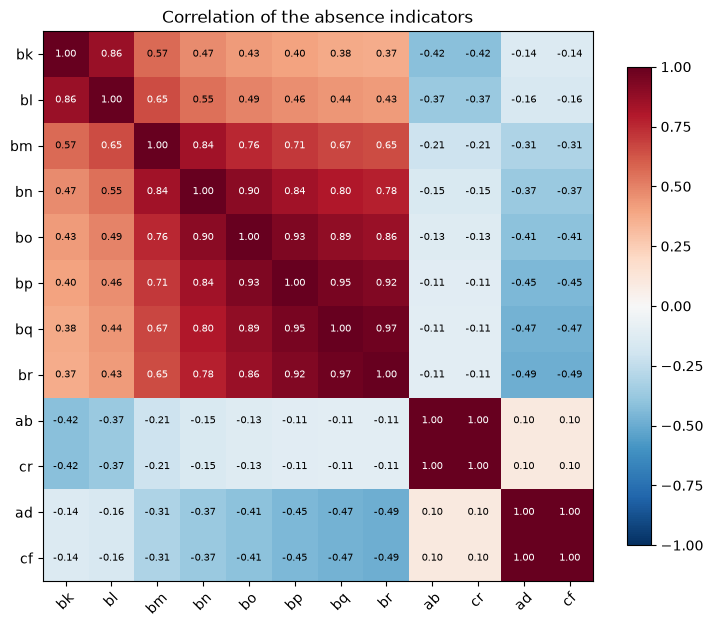

In [11]:
from src.missingness import duplicate_absence_columns

duplicates = duplicate_absence_columns(X_fit)
print('perfectly correlated absence pairs :', duplicates)

selection = groups['group1'] + [c for pair in duplicates for c in pair][:4]
matrix = X_fit[selection].isna().astype(int).corr()

fig, ax = plt.subplots(figsize=(7.5, 6.5))
image = ax.imshow(matrix.values, cmap='RdBu_r', vmin=-1, vmax=1)
labels = [c.replace('_000', '') for c in selection]
ax.set_xticks(range(len(selection)), labels, rotation=45)
ax.set_yticks(range(len(selection)), labels)
for i in range(len(selection)):
    for j in range(len(selection)):
        value = matrix.values[i, j]
        ax.text(j, i, f'{value:.2f}', ha='center', va='center', fontsize=7.5,
                color='white' if abs(value) > 0.6 else 'black')
ax.set_title('Correlation of the absence indicators')
fig.colorbar(image, ax=ax, shrink=0.8)
fig.tight_layout()
fig.savefig(FIGURES_DIR / '01_absence_correlation.png', dpi=150)

## 4. Group 1 is nested, group 2 is not

Taken in order of increasing missing rate, the eight columns of group 1 satisfy a strict
property: once a column is absent, every column after it is absent too. In the 0/1 string
of a row, that forbids the pattern `10`.

Counting distinct patterns is not a proof. Nine patterns out of 256 is what nesting
produces, but any nine patterns give the same count. The explicit forbidden-pattern test
is what establishes it.

The consequence is the useful part: a single integer, the number of absent columns,
summarises the whole block without loss. That is the `depth_g1` variable.

In [12]:
from src.missingness import nesting_report

nested = nesting_report(X_fit, groups['group1'])
print('distinct patterns :', nested['n_patterns'],
      'out of', f"{nested['n_possible']:,}",
      f"({nested['n_if_nested']} expected if nested)")
print('nested rows       :', f"{nested['nested_share']:.4%}")
print('exceptions        :', nested['n_exceptions'])
print()
print(nested['counts'].to_string())

distinct patterns : 9 out of 256 (9 expected if nested)
nested rows       : 100.0000%
exceptions        : 0

11111111    18445
00111111     9901
00000000     8562
00011111     3555
01111111     3400
00001111     1845
00000111     1098
00000011      781
00000001      413


The same test on group 2 fails, and that is a result rather than a defect. 56 columns
would give 57 patterns if they were nested; 119 are observed, and 8% of rows break the
rule outright.

This is why group 2 is not summed into a depth variable. A depth over a non-nested block
would collapse genuinely different patterns onto the same integer. Group 2 gets one flag
per absence-rate sub-block instead.

In [13]:
not_nested = nesting_report(X_fit, groups['group2'])
print('distinct patterns :', not_nested['n_patterns'],
      'out of', f"{not_nested['n_possible']:,}",
      f"({not_nested['n_if_nested']} expected if nested)")
print('nested rows       :', f"{not_nested['nested_share']:.2%}")
print('exceptions        :', f"{not_nested['n_exceptions']:,}", 'rows')
print()
print('most frequent patterns that break the nesting:')
print(not_nested['exceptions'].head(6).to_string())

distinct patterns : 115 out of 72,057,594,037,927,936 (57 expected if nested)
nested rows       : 91.96%
exceptions        : 3,860 rows

most frequent patterns that break the nesting:
00000000000000000000000000000000000000001100000000000000    1612
00000000000000000000000000000000000000001100000000011111     289
11111111111111111111111111111111111111111100000000011111     276
00000000000000000000000000000000000000000100000000000000     175
11111111111111111111111111111111111111110011111111111111     141
00000000000000000000000000000000000000110000000000000000     141


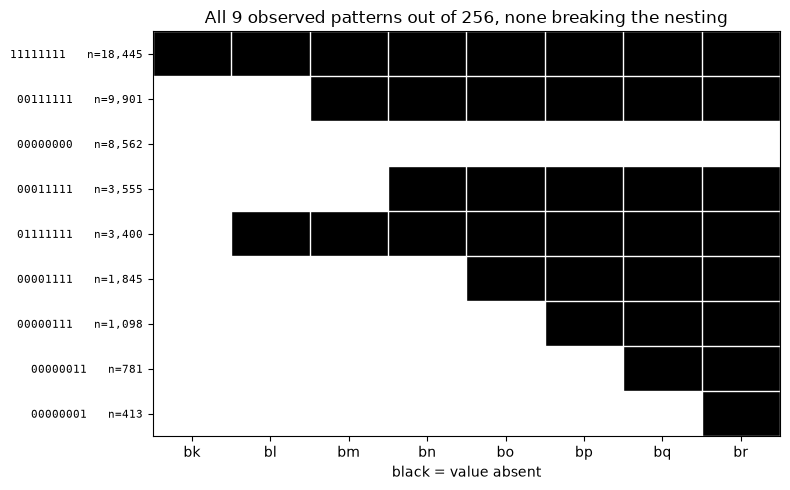

In [14]:
counts = nested['counts']
grid = np.array([[int(c) for c in pattern] for pattern in counts.index])

fig, ax = plt.subplots(figsize=(8, 5))
ax.imshow(grid, cmap='Greys', aspect='auto', vmin=0, vmax=1)
ax.set_xticks(range(len(groups['group1'])),
              [c.replace('_000', '') for c in groups['group1']])
ax.set_yticks(range(len(counts)),
              [f'{p}   n={n:,}' for p, n in counts.items()],
              fontsize=8, family='monospace')
for i in range(len(counts) + 1):
    ax.axhline(i - 0.5, color='white', lw=1)
for j in range(len(groups['group1']) + 1):
    ax.axvline(j - 0.5, color='white', lw=1)
ax.set_xlabel('black = value absent')
ax.set_title(f"All {nested['n_patterns']} observed patterns "
             f"out of {nested['n_possible']}, none breaking the nesting")
fig.tight_layout()
fig.savefig(FIGURES_DIR / '01_nesting.png', dpi=150)

## 5. What the depth variable measures

`aa_000`, the single complete column of the file, is a usage counter. Its median read at
constant class, across the levels of the depth variable, is what gives the depth a
physical reading.

The relation is not monotonic at the low end, and the table is printed rather than
summarised for that reason. What is unambiguous is the far end: at full depth the median
usage collapses by more than two orders of magnitude. Group 1 columns are absent for the
least used trucks.

This is the measurement that justifies imputing group 1 with zero rather than with a
median (decision D-10).

In [15]:
from src.missingness import depth

usage = pd.DataFrame({'depth': depth(X_fit, groups['group1']),
                      'aa_000': X_fit['aa_000'],
                      'aps': y_fit.values})

# read inside the non-APS class only, to neutralise the class effect
other = usage[usage['aps'] == 0]
print(other.groupby('depth')['aa_000'].agg(['count', 'median']).to_string())
medians = other.groupby('depth')['aa_000'].median()
print(f'\nmedian ratio, highest to lowest : '
      f'{medians.max() / max(medians.min(), 1):.0f}')

       count    median
depth                 
0       7836   61159.0
1        410  120029.0
2        777  113942.0
3       1094   87037.0
4       1843   77096.0
5       3553   56354.0
6       9898   40225.0
7       3397   29888.0
8      18392     366.0

median ratio, highest to lowest : 328


In [16]:
print('depth distribution by class, share within each class:')
print(pd.crosstab(usage['depth'], usage['aps'], normalize='columns')
        .round(4).to_string())

depth distribution by class, share within each class:
aps         0       1
depth                
0      0.1660  0.9075
1      0.0087  0.0038
2      0.0165  0.0050
3      0.0232  0.0050
4      0.0390  0.0025
5      0.0753  0.0025
6      0.2097  0.0038
7      0.0720  0.0038
8      0.3897  0.0662


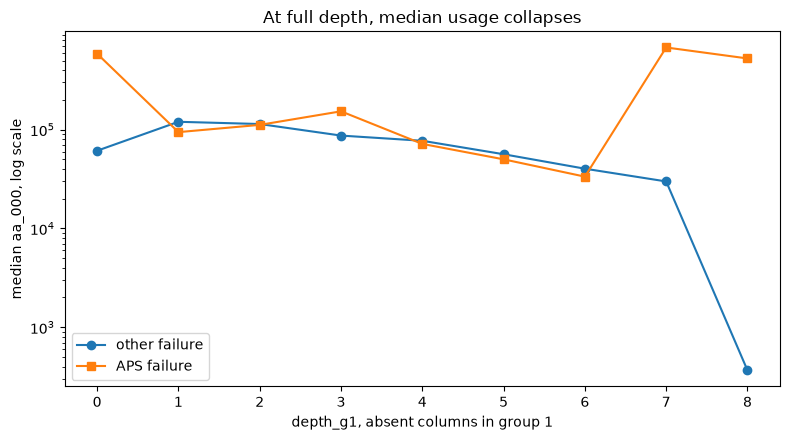

In [17]:
fig, ax = plt.subplots(figsize=(8, 4.5))
for label, marker, name in [(0, 'o', 'other failure'), (1, 's', 'APS failure')]:
    part = usage[usage['aps'] == label].groupby('depth')['aa_000'].median()
    ax.plot(part.index, part.values, marker=marker, label=name)
ax.set_yscale('log')
ax.set_xlabel('depth_g1, absent columns in group 1')
ax.set_ylabel('median aa_000, log scale')
ax.set_title('At full depth, median usage collapses')
ax.legend()
fig.tight_layout()
fig.savefig(FIGURES_DIR / '01_depth_vs_usage.png', dpi=150)

## 6. Group 2 splits into sub-blocks

The 56 columns of group 2 fall onto nine distinct missing rates. One flag per rate, not
one per column, which takes 56 columns down to 9 variables.

The flag reads one representative column per block, chosen alphabetically so the result
does not depend on the order the columns arrive in. That shortcut is only legitimate if
the columns of a block move together, so the agreement is measured rather than assumed:
the share of rows on which every column of the block is in the same state.

In [18]:
from src.missingness import MissingnessEncoder, sub_block_homogeneity, sub_blocks

blocks = sub_blocks(X_fit, groups['group2'])
for rate, members in sorted(blocks.items()):
    print(f'rate {rate:.3f} : {len(members):>2} columns  {members[:4]}'
          f"{' ...' if len(members) > 4 else ''}")
print(f'\nsub-blocks : {len(blocks)}, covering '
      f"{sum(len(m) for m in blocks.values())} of {len(groups['group2'])} columns")

rate 0.041 :  8 columns  ['ae_000', 'af_000', 'av_000', 'ax_000'] ...
rate 0.045 : 20 columns  ['ar_000', 'bc_000', 'bd_000', 'bz_000'] ...
rate 0.055 :  1 columns  ['ac_000']
rate 0.067 :  9 columns  ['df_000', 'dg_000', 'dh_000', 'di_000'] ...
rate 0.073 :  2 columns  ['ak_000', 'ca_000']
rate 0.164 :  1 columns  ['cm_000']
rate 0.170 :  1 columns  ['ec_00']
rate 0.230 :  9 columns  ['ct_000', 'cu_000', 'cv_000', 'cx_000'] ...
rate 0.247 :  5 columns  ['ad_000', 'cf_000', 'cg_000', 'ch_000'] ...

sub-blocks : 9, covering 56 of 56 columns


In [19]:
print(sub_block_homogeneity(X_fit, blocks).to_string(index=False))

 rate  n_columns  n_patterns  agreement
0.041          8           9   0.999854
0.045         20           9   0.999854
0.055          1           1   1.000000
0.067          9           5   0.999938
0.073          2           4   0.995958
0.164          1           1   1.000000
0.170          1           1   1.000000
0.230          9           2   1.000000
0.247          5           2   1.000000


In [20]:
encoder = MissingnessEncoder().fit(X_fit, y_fit)
X_fit_encoded = encoder.transform(X_fit)

print('representative columns :', encoder.representatives_)
print('columns added          :', ['depth_g1'] + encoder.flag_names_)
print('shape                  :', X_fit_encoded.shape)
print()
print(X_fit_encoded[encoder.flag_names_].mean().round(3).to_string())

representative columns : ['ae_000', 'ar_000', 'ac_000', 'df_000', 'ak_000', 'cm_000', 'ec_00', 'ct_000', 'ad_000']
columns added          : ['depth_g1', 'missing_sb1', 'missing_sb2', 'missing_sb3', 'missing_sb4', 'missing_sb5', 'missing_sb6', 'missing_sb7', 'missing_sb8', 'missing_sb9']
shape                  : (48000, 180)

missing_sb1    0.041
missing_sb2    0.045
missing_sb3    0.055
missing_sb4    0.067
missing_sb5    0.073
missing_sb6    0.164
missing_sb7    0.170
missing_sb8    0.230
missing_sb9    0.247


## 7. Zero or median for group 1

Group 1 columns carry a value on 18% of rows, and that 18% is a heavily used population.
Filling the other 82% with its median states the opposite of what the data says. Zero
already occurs legitimately in the file, so it is not an artificial value.

The cost of getting this wrong is visible in the shape of the column: after median
imputation, 82% of the rows carry one identical high value.

In [21]:
column = groups['group1'][-1]
observed = X_fit[column].dropna()
share_imputed = X_fit[column].isna().mean()

print(f'{column}')
print(f'  present on             : {1 - share_imputed:.1%} of rows')
print(f'  median of the present  : {observed.median():,.0f}')
print(f'  file minimum overall   : {X_fit.min().min():,.0f}')
print(f'  after median imputation, share on one value : {share_imputed:.1%}')
print()
load = X_fit.isna().mean()
for level in (0.10, 0.30, 0.50, 0.65):
    print(f'  columns imputed above {level:.0%} : {int((load > level).sum())}')

br_000
  present on             : 17.8% of rows
  median of the present  : 315,740
  file minimum overall   : 0
  after median imputation, share on one value : 82.2%

  columns imputed above 10% : 28
  columns imputed above 30% : 10
  columns imputed above 50% : 8
  columns imputed above 65% : 8


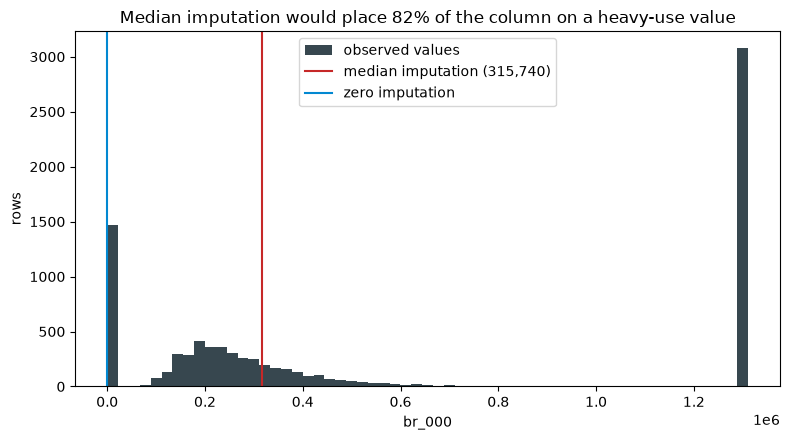

In [22]:
fig, ax = plt.subplots(figsize=(8, 4.5))
bins = np.linspace(0, observed.quantile(0.99), 60)
ax.hist(observed, bins=bins, color='#37474f', label='observed values')
ax.axvline(observed.median(), color='#c62828', lw=1.5,
           label=f'median imputation ({observed.median():,.0f})')
ax.axvline(0.0, color='#0288d1', lw=1.5, label='zero imputation')
ax.set_xlabel(column)
ax.set_ylabel('rows')
ax.set_title(f'Median imputation would place {share_imputed:.0%} '
             f'of the column on a heavy-use value')
ax.legend()
fig.tight_layout()
fig.savefig(FIGURES_DIR / '01_imputation_effect.png', dpi=150)

## What comes out of this notebook

**D-09.** Absence carries class information. Group 1, eight nested columns, becomes one
ordinal depth variable. Group 2, 56 columns that are *not* nested, becomes 9 sub-block
flags. The variables are built before imputation, which would otherwise destroy the
pattern. Detection runs on the fitting split only.

**D-10.** Group 1 is imputed with zero, the other columns with their median. The depth
variable and the flags are left unscaled.

**Two figures worth keeping in mind for later.** The stratified split is exact by
construction where an unstratified one wanders across the break-even rate; and the 0.10
threshold sits inside a real break on the group 1 side but not on the group 2 side.

`scripts/build_dataset.py` replays this chain end to end and asserts every figure
printed above.